## Methods of Machine Learning (MAT 3373 A00) Short Homework Assignment 1
### Alex Hills 300241757

In [123]:
# Python imports:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
import numpy as np

# Setting up the dataframes for SchoolA.csv, SchoolB.csv and SchoolC.csv
school_a = pd.read_csv("CSV_Files/SchoolA.csv", names=["IQ", "Diligence"], header=0)
school_b = pd.read_csv("CSV_Files/SchoolB.csv", names=["IQ", "Diligence"], header=0)
school_c = pd.read_csv("CSV_Files/SchoolC.csv", names=["IQ", "Diligence"], header=0)

***

## Part 1

(Copied from assignment description): Some psychologists would like to study the following (informal) question: does being smarter have an influence on diligence? They start to answer this question by defining some test that is intended to measure diligence, then getting all of the students at a university A to report both their IQ and their results on a diligence test. The data are in the file SchoolA.csv, with the first column corresponding to IQ.

We will fit this data to the standard linear regression model:  $Y_i = \beta_0 + \beta_1X_i + \epsilon_i$

where the $X_i$’s are IQ and the $Y_i$’s should be diligence

To answer this question:

1. Write down a hypothesis test for $\beta_1$ that corresponds to the informal question.
2. Fit the model and write down the results of the hypothesis test.
3. You should check if the residuals are (roughly) Gaussian. Display an appropriate plot, and
mention if they seem to be Gaussian based on the plot.

***

### 1.1: Hypothesis test for β1:  
Null Hypothesis: $H_0:\beta_1 = 0$  
Alt. Hypothesis: $H_1:\beta_1 \neq 0$

Where $H_0$ corresponds to there being no linear relationship between IQ scores and diligence, and $H_1$ being that there is some linear relationship, positive or negative.

Then the test-statistic is:  $t=\frac{\hat\beta_1}{SE(\hat\beta_1)}$  

Which we input into the student's t-distribution with $n-2$ degrees of freedom (in this case, $n\approx50000$) to get the p-value, however we will use Python to compute this value rather than computing by hand. 

### 1.2: Fitting the Model:

In [124]:
# Fitting the model (using sklearn)

x = school_a[["IQ"]]
y = school_a["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

Slope (beta_1): [-0.5545756]
Intercept (beta_0): 173.42780332359126


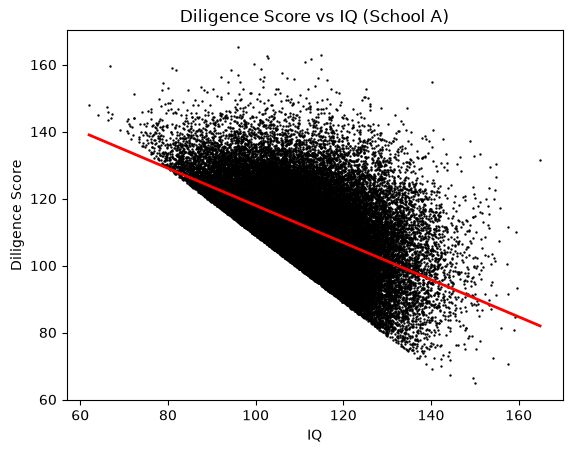

In [125]:
# Plotting the regression 

x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School A)")
plt.show()

In [126]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_a = stats.linregress(school_a["IQ"], school_a["Diligence"]) 
t_stat = result_a.slope / result_a.stderr
print("t-stat:", t_stat)
print("p-value:", result_a.pvalue)

t-stat: -149.8264451746288
p-value: 0.0


#### Hypothesis Test Conclusion
Therefore there is very strong evidence ($p-value\ll0.05$) to suggest a linear relationship between IQ and diligence in School A, enough to reject the null hypothesis (specifically a negative relationship, though our alternative hypothesis was only that there is some relationship, either positive or negative). 

Note: while the computed p-value above reads as 0.0, that does not literally mean a p-value of 0, only that the computed value is so small that SciPy returns it as such.

***

### 1.3: Plotting the residuals

To check the normality of the residuals, I used both a histogram and a normal Q-Q plot. The histogram, superimposed with a true normal distribution based on the sample mean and standard deviation, provides an intuitive visual evaluation of the overall shape of the data. The Q-Q plot, meanwhile, provides a more precise look, making it easier to detect subtle deviations from normality. I think the instructions only strictly require one plot, but they don't say we can't make more. (if I had to choose one it'd be the Q-Q plot, but I appreciate how intuitive the histogram is). 

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit')

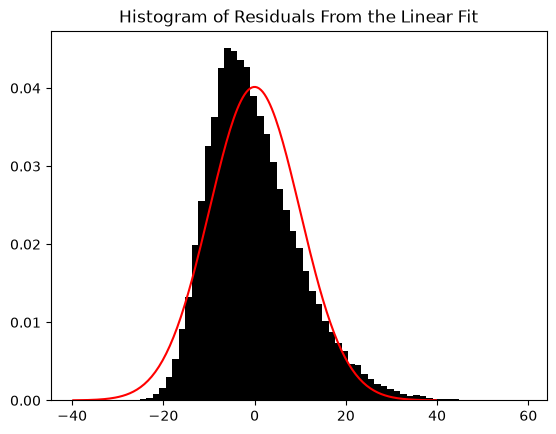

In [127]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit")

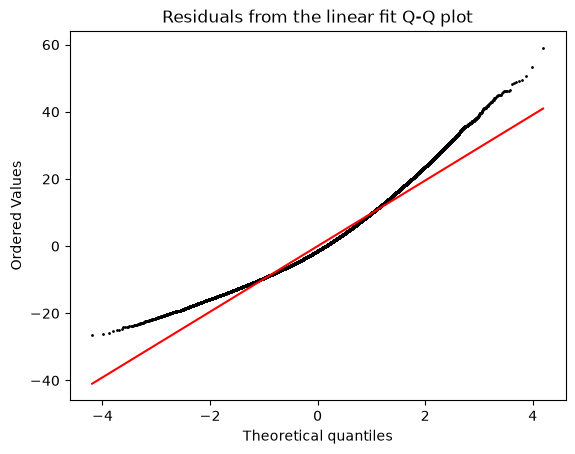

In [128]:
# Creating a Q-Q plot for the residuals. 

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot")

# Accesses scatter points component of the QQ-plot (just to customize them to match the design of my other plots haha)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

#### Residuals Analysis

The residuals appear distinctly non-Gaussian, as shown in the histogram with the superimposed true normal distribution and the Q-Q plot with the normal reference line. 

In the histogram, the right tail extends much farther than the left, suggesting a positively skewed distribution, and in the Q-Q plot, the residuals form an upward curve above the reference line rather than following it linearly, which is also indicative of a positively skewed distribution.

***

## Part 2

(Copied from assignment description): The city has three large universities. The first university, A, is the most selective. The second, B, is less selective. The third, C, is not selective. 

Researchers at B and C hear about this study, and decide to replicate it. Their data are in SchoolB.csv and SchoolC.csv.

To answer this question:
1. Repeat the same analysis as above for the new datasets. Hint: If your computing setup is good, this should involve almost no new work—just changing a few characters. If this is substantial work, you’re doing something wrong and should ask for help.
2. Check—do all three studies give (roughly) the same answer for the relationship between intelligence and diligence? Note: I’m not asking for a formal hypothesis test on whether the three coefficients could be exactly the same. I’m only asking if the three estimates all seem to support the same rough relationship between intelligence and diligence.


***
### 2.1: Repeating the analysis for schools B and C

#### School B

In [129]:
# Fitting the model (using sklearn)

# School B
print("SCHOOL B:")
x = school_b[["IQ"]]
y = school_b["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

SCHOOL B:
Slope (beta_1): [-0.89010174]
Intercept (beta_0): 189.0562902048652


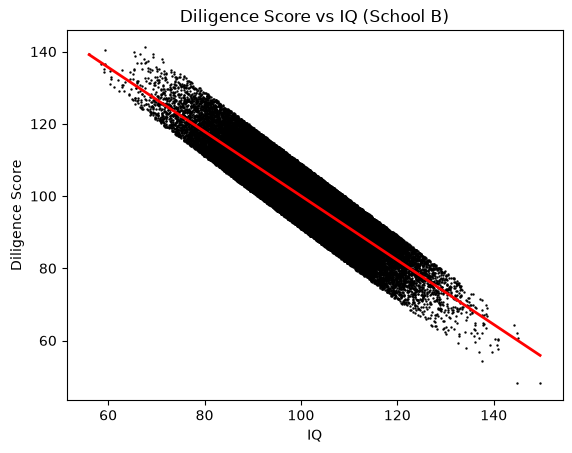

In [130]:
# Plotting the regression

# School B
x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School B)")
plt.show()

In [131]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_b = stats.linregress(school_b["IQ"], school_b["Diligence"]) 
t_stat = result_b.slope / result_b.stderr
print("t-stat:", t_stat)
print("p-value:", result_b.pvalue)

t-stat: -434.7858919454757
p-value: 0.0


#### Hypothesis Test Conclusion
Therefore, like in school A, there is very strong evidence ($p-value\ll0.05$) to suggest a (negative) linear relationship between IQ and diligence in school B, enough to reject the null hypothesis. 

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit')

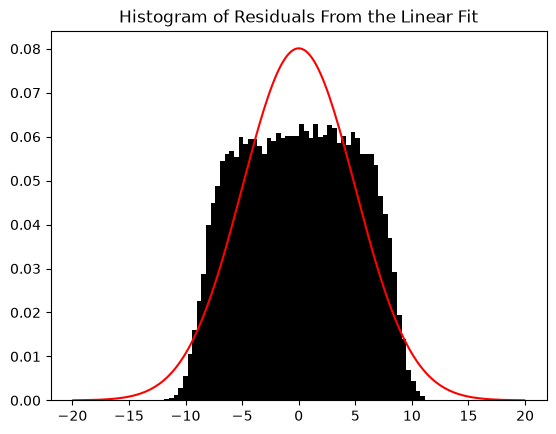

In [132]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit")

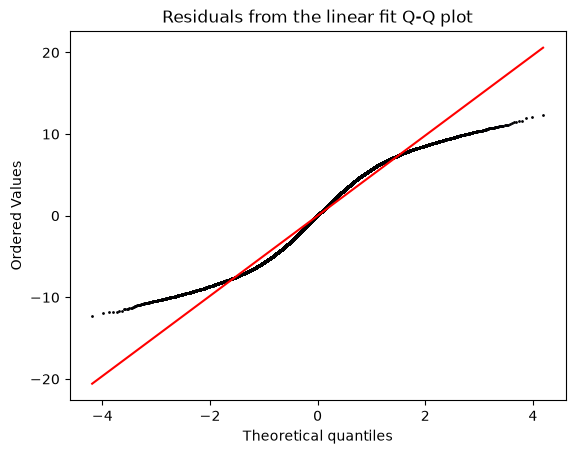

In [133]:
# Creating a Q-Q plot for the residuals. 

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot")

# Accesses scatter points component of the QQ-plot (to colour them)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

#### Residuals Analysis

The residuals for school B appear non-Gaussian as well, albeit for a different reason than school A. We would call this kind of distribution "light-tailed" or "platykurtic," evidenced by the histogram's wide, flat top and sudden fall-off at the tails rather than a gradual dispersion. The Q-Q plot supports this as well, in which the residuals appear as a clear s-shaped ("sigmoidal") curve around the reference line, above it on the left and below it on the right. 

***
#### School C

In [134]:
# Fitting the model (using sklearn)

# School C
print("SCHOOL C:")
x = school_c[["IQ"]]
y = school_c["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

SCHOOL C:
Slope (beta_1): [-0.56171098]
Intercept (beta_0): 138.22679862140916


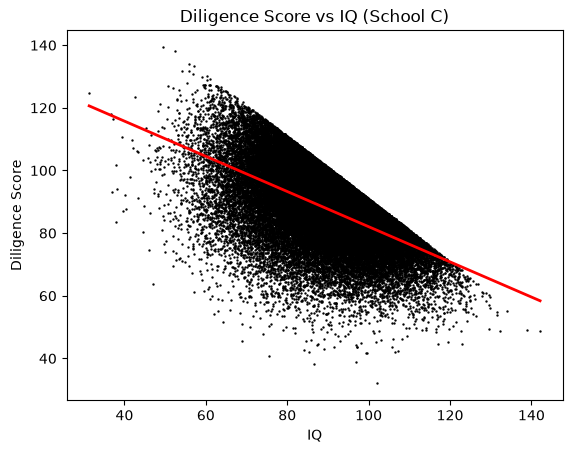

In [135]:
# Plotting the regression

# School C
x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School C)")
plt.show()

In [136]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_c = stats.linregress(school_c["IQ"], school_c["Diligence"]) 
t_stat = result_c.slope / result_c.stderr
print("t-stat:", t_stat)
print("p-value:", result_c.pvalue)

t-stat: -151.95161512354616
p-value: 0.0


#### Hypothesis Test Conclusion
Once again, there is very strong evidence ($p-value\ll0.05$) to suggest a (negative) linear relationship between IQ and diligence in school C, enough to reject the null hypothesis. 

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit')

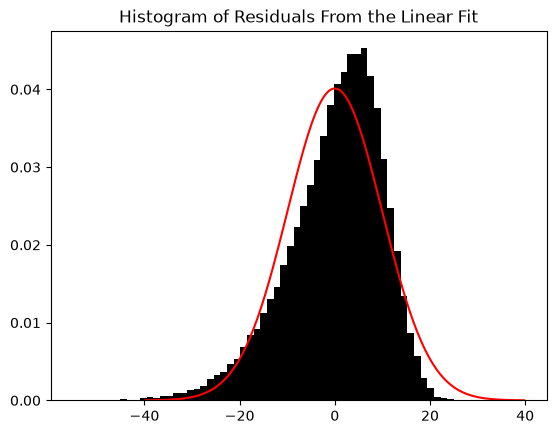

In [137]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit")

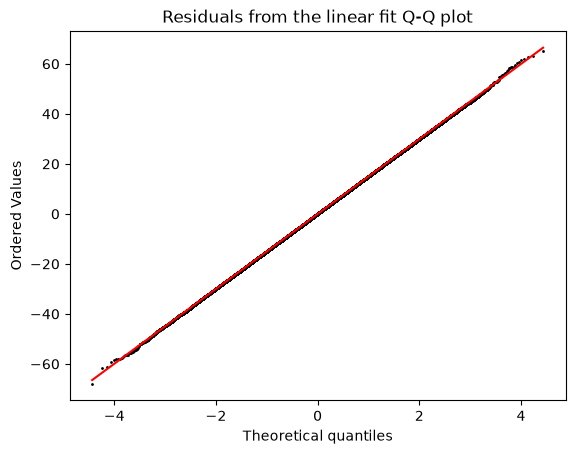

In [144]:
# Creating a Q-Q plot for the residuals.

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot")

# Accesses scatter points component of the QQ-plot (to colour them)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

#### Residuals Analysis

Once again, the residuals for school C appear non-Gaussian, this time for a similar reason to school A, albeit reversed. That is to say, rather that exhibiting a positive-skewness like school A, school C exhibits a negative-skewness: the residuals extend further to the left than the right and the Q-Q plot shows a downwards curve below the reference line.

***

## Part 3



At this point, three independent experiments have been done with the same hypothesis and same experimental setup. Researchers interested in the hypothesis realize that they can combine the three experiments to get more precise answers.

1. Theory question: Assume that we have three datasets (each with at least two distinct X-values) drawn from the linear regression model with the same parameter values and known variance for the residuals. Check that, as the researchers suggest, combining independent datasets will always result in smaller (and thus better) confidence intervals for $\beta_1$. Note: Setting up the notation may take a few lines, but the proof itself is very short.
2. Carry out the same analysis as in Parts 1 and 2, this time for the merged data set. Do the answers agree with those in Parts 1 and 2?
3. You have probably found some amount of conflict in answering the last question. Suggest a scientific explanation for this apparent conflict. Your explanation should not use any technical words such as “residual” or “confidence interval.” Illustrate this answer with an appropriate plot.

***

### 3.1: Theory Question

blah blah blah blah blah therefore blah. QED.

***

### 3.2: Merged Dataset Analysis


In [139]:
# Combine three dataframes into one large dataframe
merged_df = pd.concat([school_a, school_b, school_c], ignore_index=True)


# Fitting the model (using sklearn)

print("MERGED DATASET:")
x = merged_df[["IQ"]]
y = merged_df["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

MERGED DATASET:
Slope (beta_1): [0.00066073]
Intercept (beta_0): 99.94581809709764


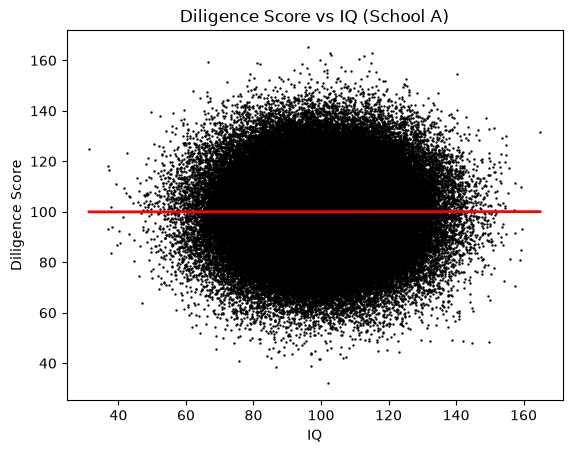

In [140]:
# Plotting the regression 

x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School A)")
plt.show()

In [141]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_merged = stats.linregress(merged_df["IQ"], merged_df["Diligence"]) 
t_stat = result_merged.slope / result_merged.stderr
print("t-stat:", t_stat)
print("p-value:", result_merged.pvalue)

t-stat: 0.256083291892151
p-value: 0.7978868742393707


#### Hypothesis Test Conclusion

With the merged datasets, the $p-value$ came to be approximately 0.798, which by any standard choice of $\alpha$ (e.g. 0.05), means we should fail to reject the null hypothesis. That is to say, there is insufficient evidence to suggest a linear relationship between IQ and diligence within the three schools.

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit')

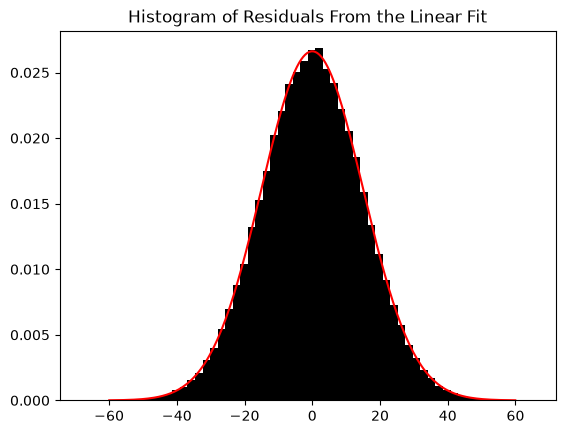

In [142]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit")

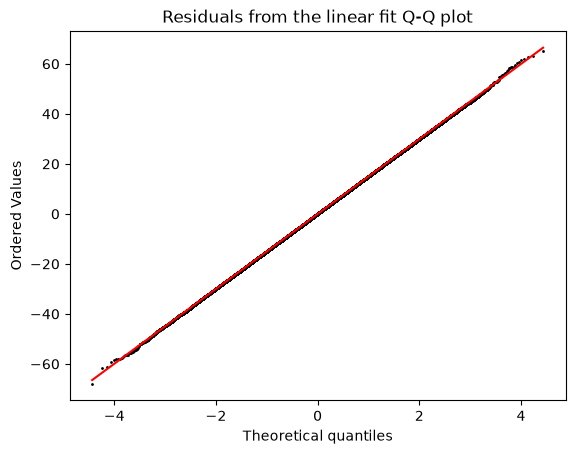

In [145]:
# Creating a Q-Q plot for the residuals.

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot")

# Accesses scatter points component of the QQ-plot (to colour them)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

#### Residuals Analysis

With the merged datasets, the distribution of residuals now strongly appears Gaussian, with the histogram and Q-Q Plot following the theoretical distribution almost exactly. 

***

### 3.3: Explanation of Apparent Conflict
